# Subsample a set of input genomes to minimize overrepresentation in gene-by-gene schema

## Introduction

### Aim
Subsample a set of Giardia genomes to reduce overrepresentation of highly similar assemblies in a gene-by-gene schema 

### Analysis steps

1. Create a distance matrix obtained using **sourmash** (kmer size = 51) by sketching the whole genome and aproximating the ANI
2. Use a clustering method to determine the similarity among them. To preserve the **Average Nucleotide Identity** calculated with **sourmash**, we used **AgglomerativeClustering**
3. After selecting (with additional visualization with UMAP to preserve local and global relationships) we will subset any cluster that is solely or mostly represented by the BC isolates

The **data input** is a square matrix of pre-calculated mash distances (**sourmash v4.8.9**) from genome assemblies determined to be of good enough quality based on assembly metrics.

## Define dependencies and load data

The python environment required for this notebook can be reproduced using the `environment.yml` on this directory.

In [ ]:
# Import all dependencies 

import warnings
import umap
import re
import pandas   as pd
import numpy    as np
import seaborn  as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

/home/mdprieto/virtual_envs/tsne_env2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import the data and metadata for the genome assemblies. 


In [5]:
# The column names of the distance matrix contain the identifiers, we saved them into the rownames
sour_data = pd.read_csv('../../output/sourmash/sourmash_distances_hq_genomes.csv', sep=',')
sour_data.columns = sour_data.columns.str.replace('.*/', '', regex=True)
sour_data.index = sour_data.columns

# Load the metadata
sour_metadata = pd.read_csv('../../input_data/metadata/merged_SraPrystajecky.csv', sep=',')

# Define a random seed for reproducibility
project_seed = 1113

Create several dictionaries that contain the mapping keys to connect the identifiers with the metadata. 

In [6]:

# Lookup dictionaries to connect metadata and distance matrix
isolate_map         = {}
host_map            = {}
country_map         = {}
location_map        = {}
region_map          = {}
date_collection_map = {}

for _, row in sour_metadata.iterrows():
    # Get best possible location data
    country = str(row['country_geoloc']).lower().strip()
    region = str(row['region_geoloc']).lower().strip()
    if country and region:
        location_value = f"{country}_{region}"
    else:
        location_value = country if country else (region if region else "Unknown")

    for identifier in [row['run'], row['biosample']]:
        isolate_map[identifier]         = str(row['isolate']).replace("/", "-")
        host_map[identifier]            = str(row['isolation_source'])
        country_map[identifier]         = country
        region_map[identifier]          = region
        location_map[identifier]        = location_value
        date_collection_map[identifier] = str(row['collection_date'])

Use the **AgglomerativeClustering** algorithm to define what samples are mostly similar. This algorithm is deterministic and does not force a particular number of clusters. Additionally, it preserves the hierarchical structure of the input distances.

The threshold for MASH distances can be set manually, a good baseline looks for 95% similarity. 

In [7]:
# -----------------------------------------------------------------------------------------------
# Set distance threshold cut-off to define a group
dist_thresh = 0.03
# -----------------------------------------------------------------------------------------------where


# Linkage 'average' is great for genomics as it balances group distances.
cluster_model = AgglomerativeClustering(
    n_clusters=None, 
    distance_threshold=dist_thresh, 
    metric='precomputed', 
    linkage='average'
)
clusters = cluster_model.fit(sour_data)

# Assign metadata to clusters
vector_mat = pd.DataFrame(index=sour_data.index)

vector_mat['cluster_id'] = clusters.labels_
vector_mat['raw_id'] = vector_mat.index.to_series().astype(str).str.split('_').str[-1]

vector_mat['cluster_id']        = cluster_model.fit_predict(sour_data)
vector_mat['Region']            = vector_mat['raw_id'].map(region_map).fillna("Unknown")
vector_mat['Host']              = vector_mat['raw_id'].map(host_map).fillna("Unknown")
vector_mat['Collection_date']   = vector_mat['raw_id'].map(date_collection_map).fillna("Unknown")
vector_mat['Collection_date']   = pd.to_datetime(vector_mat['Collection_date'])
vector_mat['year']              = vector_mat['Collection_date'].dt.year


To visualize, we take a look at UMAP embeddings. And to verify the stability of the cluster, we are conducting several embeddings by varying the number of important neighbors. 

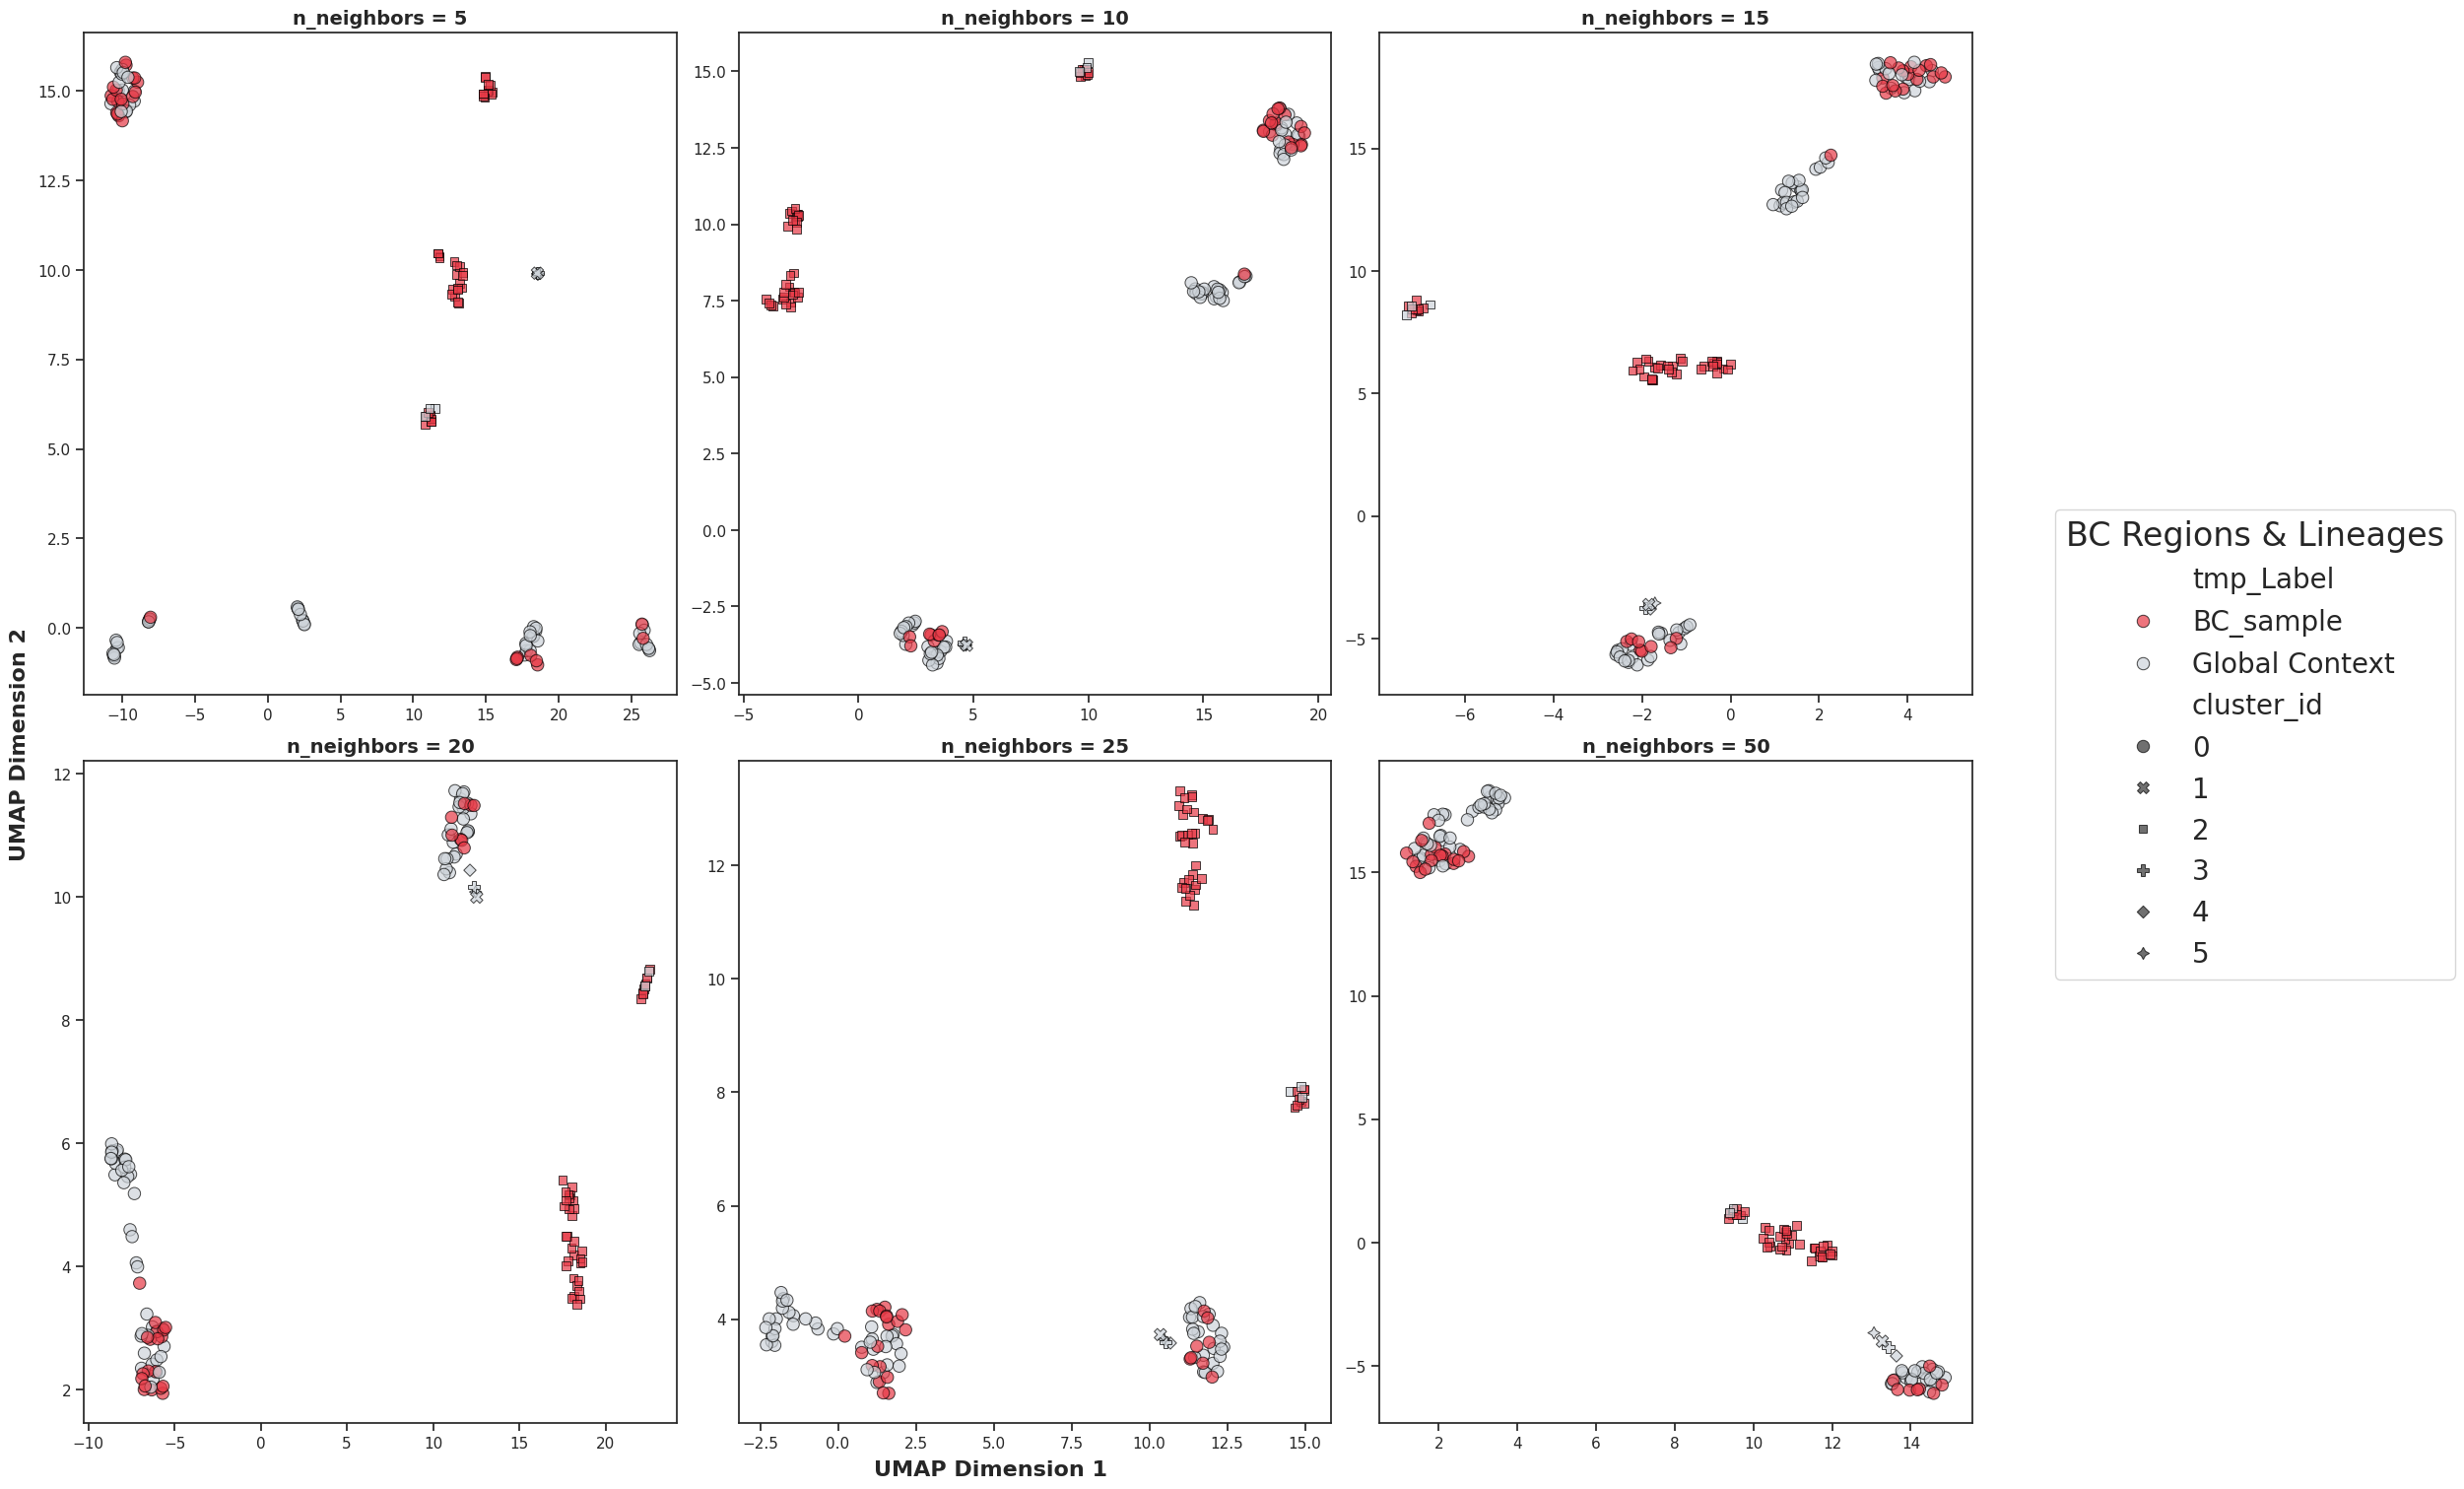

In [13]:
# Set plotting space
fig, axes = plt.subplots(2, 3, figsize=(20, 15), sharex=False, sharey=False, constrained_layout=True)
axes = axes.flatten()

# Ignore warning messages while plotting
warnings.filterwarnings("ignore", message="using precomputed metric")
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden")

# Function to label the BC samples in the subcluster
def get_audit_label(row, u2_col, threshold=None):

    region_str = str(row.get('Region', '')).lower()
    is_bc = bool(re.search(r'\bbc\b', region_str))
    cid = str(row['cluster_id'])

    if threshold:
        if cid == "2" and is_bc and row[u2_col] > threshold:
            return "BC_Only"
        elif is_bc:
            return "BC_other"
        else:
            return "Global Context"
    elif is_bc:
        return "BC_sample"
    else:
        return "Global Context"


custom_palette = {
    "BC_sample": "#e63946",     # Red
    "Global Context": "#ced4da" # Grey
}

# Plot embeddings at different neighbors
for i, neighbors_n in enumerate([5, 10, 15, 20, 25, 50]):

    neighbors_df = vector_mat.copy()
    
    # Initialize UMAP with 'precomputed' metric of distance data
    reducer = umap.UMAP(
        n_neighbors=neighbors_n, 
        min_dist=0.1, 
        metric='precomputed', 
        random_state=project_seed
        )
    
    # Extract the embeddings and add them to our primary dataframe
    embedding = reducer.fit_transform(sour_data)
    neighbors_df['tmp_U1'] = embedding[:, 0]
    neighbors_df['tmp_U2'] = embedding[:, 1]

    neighbors_df['tmp_Label'] = neighbors_df.apply(lambda r: get_audit_label(r, 'tmp_U2'), axis=1)

    sns.scatterplot(
        data=neighbors_df, 
        x='tmp_U1', y='tmp_U2', 
        hue='tmp_Label', style='cluster_id',
        hue_order=["BC_sample", "Global Context"],
        ax=axes[i], palette=custom_palette, s=80, alpha=0.7, edgecolor='black'
    )
    
    axes[i].set_title(f"n_neighbors = {neighbors_n}", fontsize=14, weight="bold")
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].get_legend().remove()

# Customization of unified axes and legend
fig.supxlabel("UMAP Dimension 1", fontsize=16, fontweight='bold')
fig.supylabel("UMAP Dimension 2", fontsize=16, fontweight='bold')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', title='BC Regions & Lineages', 
           title_fontsize=24, fontsize=20, bbox_to_anchor=(1.25, 0.5))

plt.show()



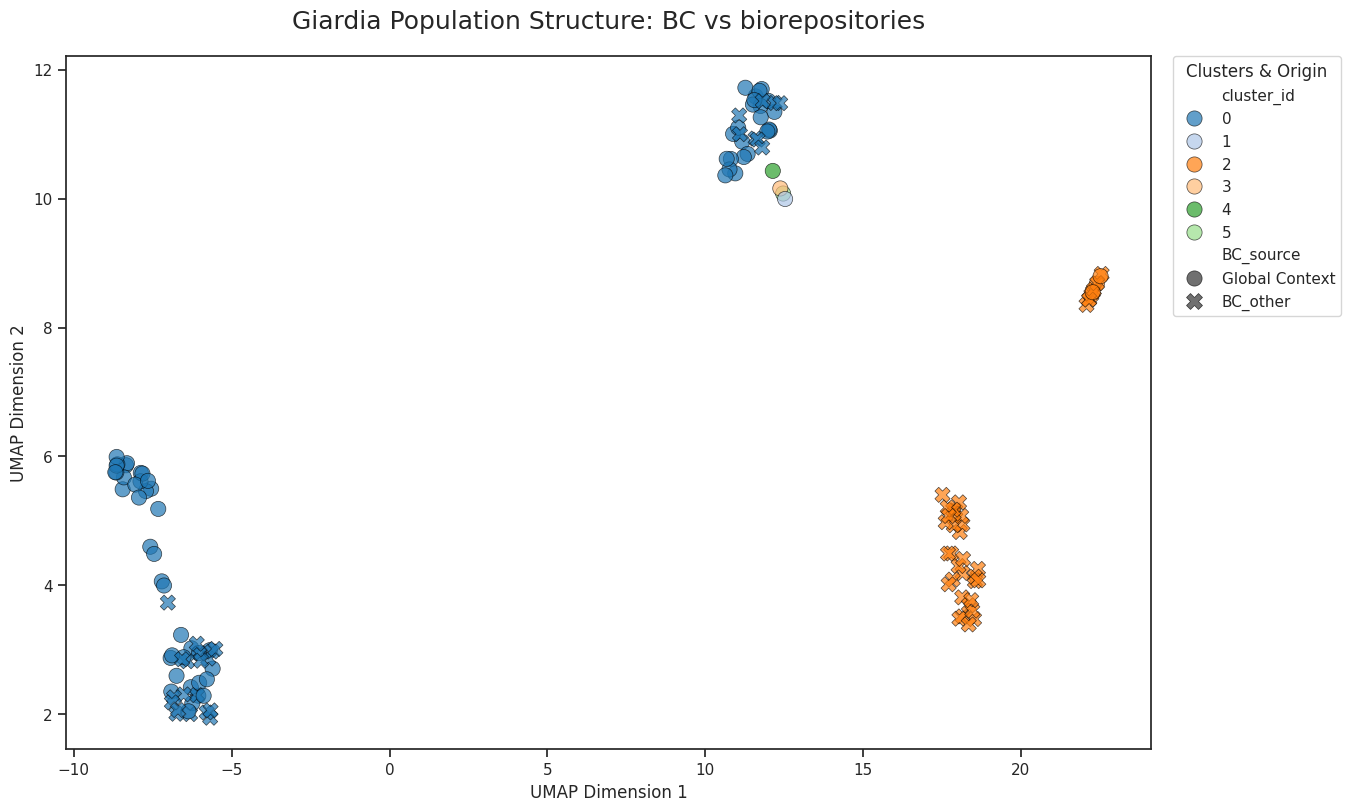

In [14]:
# -----------------------------------------------------------------------------------------------
# Number of influential neighbors based on stable clusters in the previous snippet
neighbors_chosen = 20
# -----------------------------------------------------------------------------------------------

# Save the embedding coordinates into the results dataset
reducer = umap.UMAP(
    n_neighbors=neighbors_chosen, 
    min_dist=0.1, 
    metric='precomputed', 
    random_state=project_seed
    )

embedding = reducer.fit_transform(sour_data)
vector_mat['UMAP-1'] = embedding[:, 0]
vector_mat['UMAP-2'] = embedding[:, 1]

# Label clusters with only BC samples 
vector_mat['BC_source'] = vector_mat.apply(lambda r: get_audit_label(r, 'UMAP-2', 10), axis=1)

# Scatterplot using UMAP coordinates and labelling by 'BC_source' and 'cluster_id'
sns.set_theme(style="ticks")
plt.figure(figsize=(14, 9))
plot = sns.scatterplot(
    data=vector_mat,
    x='UMAP-1', 
    y='UMAP-2',
    hue='cluster_id',
    style='BC_source',
    palette='tab20',
    s=120,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
    )

# Clean up the labels and legend
plt.title(f"Giardia Population Structure: BC vs biorepositories", fontsize=18, pad=20)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

# Move the legend outside so it doesn't cover your data
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Clusters & Origin')


### Validation and export

Calculate frequency tables showcasing the initial and adjusted distribution of labels. I will subsample 

The data is exported to define the gene-by-gene schema in the `nf_chewbbaca` pipeline

In [19]:
def label_subclusters(row, threshold, mode, cluster_id_value):
    """"
    Flexible filter to select samples in BC only subcluster
    """
    is_bc = bool(re.search(r'\bbc\b', str(row.get('Region', '')).lower()))
    cluster_match = str(row.get('cluster_id')) == str(cluster_id_value)
    

    if mode == 'above':
        threshold_met = row['UMAP-2'] > threshold
    else:
        threshold_met = row['UMAP-2'] < threshold

    if cluster_match and is_bc and threshold_met:
        return 'BC_Only'
    return 'BC Samples' if is_bc else 'Global Context'

vector_mat['Clean_source'] = (
    vector_mat
        .apply(
            lambda row: label_subclusters( row, 7, 'below', 2),
            axis=1
        )
)

# Create the summary table
test_counts = vector_mat['Clean_source'].value_counts().reset_index()
test_counts.columns = ['Category', 'Count']

# Display the table
test_counts


,Category,Count
0,Global Context,69
1,BC Samples,35
2,BC_Only,31
